# Dataset Overview

The dataset used in this study is obtained from **PJM Interconnection LLC (PJM)**, a regional transmission organization (RTO) in the United States. PJM operates an electric transmission system serving all or parts of the following regions:



- Delaware
- Illinois
- Indiana
- Kentucky
- Maryland
- Michigan
- New Jersey
- North Carolina
- Ohio
- Pennsylvania
- Tennessee
- Virginia
- West Virginia
- District of Columbia

The hourly power consumption data, measured in megawatts (MW), is sourced from PJM's official website. This study focuses on **PJM East**, which provides data spanning from 2002 to 2018 for the entire eastern region.

### Dataset Description

The dataset includes the following columns:

- **Datetime**: The timestamp of the energy consumption measurement (in hourly intervals).
- **PJME_MW**: The energy consumption in megawatts (MW) for the PJM East region at the given timestamp.

### Key Statistics

- **Total Observations**: 145,366 hourly records.
- **Time Period**: 2002 to 2018.

### Data Preprocessing

The dataset has been cleaned and preprocessed to address missing values and ensure consistency, making it suitable for time series analysis and forecasting.

---

# Exploratory Data Analysis (EDA)

This section explores the **PJM East energy consumption dataset** to understand its:

- Distribution
- Trends (there no trend or volatily in our time serie data)
- Patterns over time

The EDA serves as a foundation for identifying key insights and preparing the data for further modeling and forecasting tasks.


In [34]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
import matplotlib.patches as patches
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)


warnings.filterwarnings("ignore")

In [35]:
df = pd.read_csv('PJME_hourly.csv')
display(df.info())
df = df.set_index('Datetime')
#transforming data into datetime type
df.index = pd.to_datetime(df.index)
df = df.sort_index()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB


None

In [36]:
def create_hour_month_year(df):

    df = df.copy()
    df['hour'] = df.index.hour     
    df['month'] = df.index.month    
    df['year'] = df.index.year      
    df['dayofmonth'] = df.index.day 
    
    return df

data = create_hour_month_year(df) # We will use it after in the modelisation
data.head()

,PJME_MW,hour,month,year,dayofmonth
Datetime,,,,,
2002-01-01 01:00:00,30393.0,1,1,2002,1
2002-01-01 02:00:00,29265.0,2,1,2002,1
2002-01-01 03:00:00,28357.0,3,1,2002,1
2002-01-01 04:00:00,27899.0,4,1,2002,1
2002-01-01 05:00:00,28057.0,5,1,2002,1


In [37]:
print(df.shape)
print(df.isnull().sum())
df.head()

(145366, 1)
PJME_MW    0
dtype: int64


,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


## Descriptive Statistics
The dataset contains **145,366 hourly observations** of energy consumption measured in megawatts (MW). The descriptive statistics are as follows

In [38]:
df.describe()

,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


0.7390115207783632


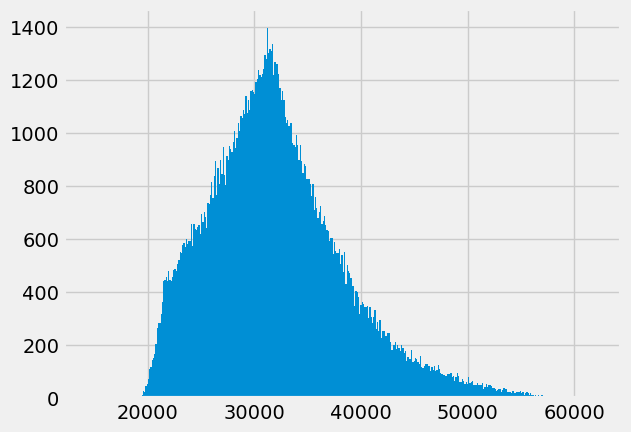

CPU times: total: 922 ms
Wall time: 889 ms


In [39]:
%%time
print((df.PJME_MW.skew()))
df.PJME_MW.hist(bins=400)
plt.show()

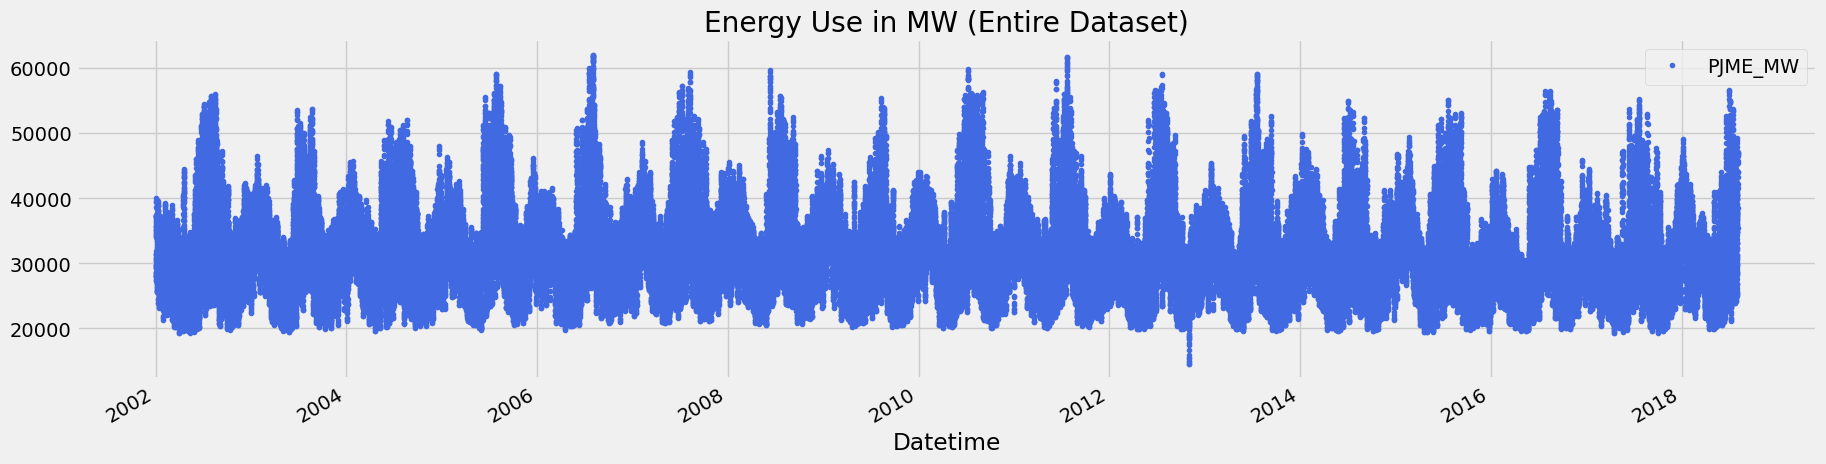

In [40]:
df.plot(style='.',
        figsize=(20, 5),
        color='royalblue',
        title='Energy Use in MW (Entire Dataset)')
plt.show()

The time series plot of the entire dataset reveals strong **seasonality**, withpeaks occurring midway through each year. This suggests higher energy consumption during summer and winter months.

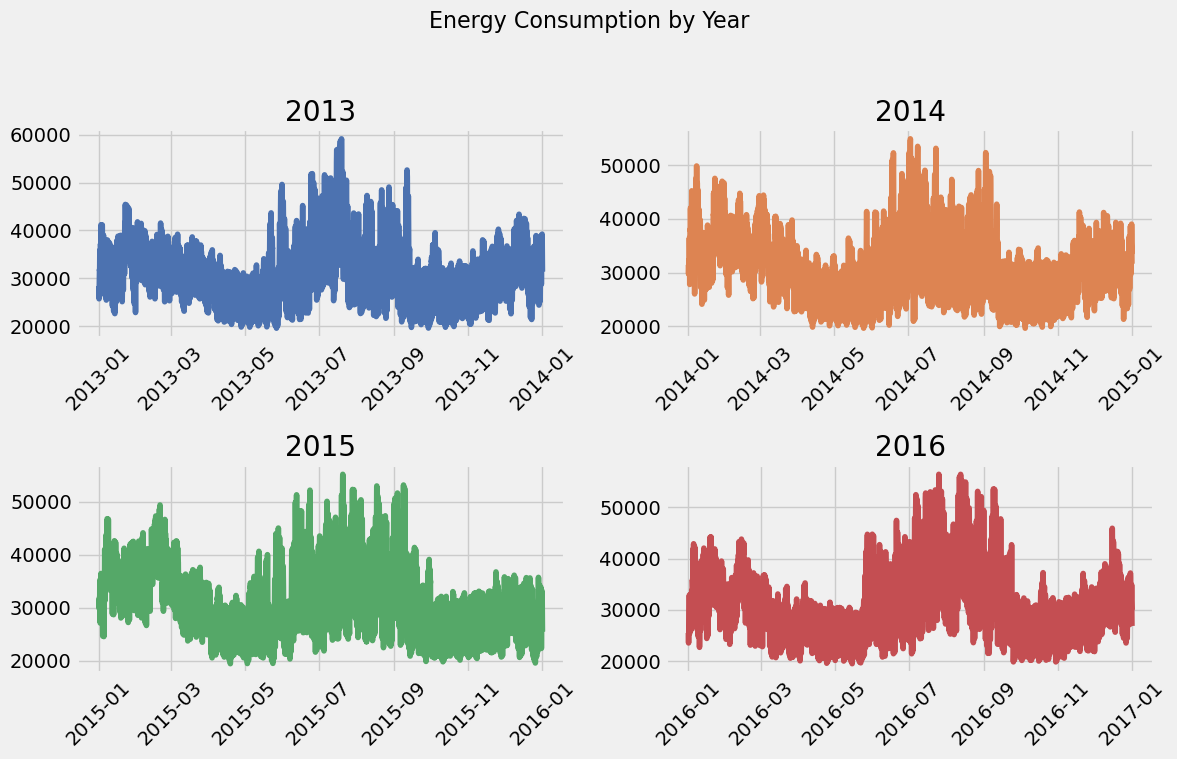

CPU times: total: 1.38 s
Wall time: 1.44 s


In [41]:
%%time
year_one = df.loc[(df.index >= '2013-01-01 01:00:00') & (df.index <= '2014-01-01 01:00:00')]
year_two = df.loc[(df.index >= '2014-01-01 01:00:00') & (df.index <= '2015-01-01 01:00:00')]
year_three = df.loc[(df.index >= '2015-01-01 01:00:00') & (df.index <= '2016-01-01 01:00:00')]
year_four = df.loc[(df.index >= '2016-01-01 01:00:00') & (df.index <= '2017-01-01 01:00:00')]
years = [year_one, year_two, year_three, year_four]
year_labels = ['2013', '2014', '2015', '2016']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
fig.suptitle('Energy Consumption by Year', fontsize=16)

axes = axes.flatten()

colors = sns.color_palette('deep', 4)

for i, year in enumerate(years):
    axes[i].plot(year.index, year['PJME_MW'], color=colors[i])
    axes[i].set_title(year_labels[i])
    axes[i].set
    
    
    axes[i].tick_params(axis='x', rotation=45)  # rotate x-axis labels for better readability

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout
plt.show()

To further analyze the **seasonal patterns**, the dataset was divided into yearly segments (2013–2016). The previous figure shows hows the energy consumption trends for each year. **The patterns are consistent** across years, with **higher** consumption in summer and winter and **lower** consumption in spring and fall.

The figure below illustrates the weather conditions in the eastern region. The averages are based on data from the **Petersburg Weather Reporting System**, located 22 kilometers from the East Coast, collected between 1992 and 2021.

<div style="text-align: center;">
  <img src="img/Average%20weather%20in%20the%20East%20region%20in%20the%20USA%20in%20C%20during%201992-2021.png" alt="de" width="600">
</div>


We can assume that the relationship between temperature and electricity consumption in this region is **quadratic**, as electrical consumption tends to increase at extreme temperature values (both minimum and maximum), while remaining relatively low at intermediate values.

However, without access to hourly temperature data for this region, we cannot verify this hypothesis. Having such data would likely improve the performance of a predictive model.

In [42]:
def create_features(df):
    """
    Create time series features based on time series index.
    Each feature captures different temporal patterns and cycles.
    """
    df = df.copy()
    
    # Basic time components
    df['hour'] = df.index.hour           # Captures hourly patterns (0-23), like peak hours
    df['month'] = df.index.month         # Captures monthly patterns (1-12), like end-of-month effects
    df['year'] = df.index.year           # Captures yearly trends and long-term patterns
    df['dayofmonth'] = df.index.day      # Captures monthly cycles (1-31),
    
    return df

data = create_features(df)

## Hourly and Monthly Patterns
The boxplots in the two figures below, provide insights into energy consumption patterns by hour and month, respectively.

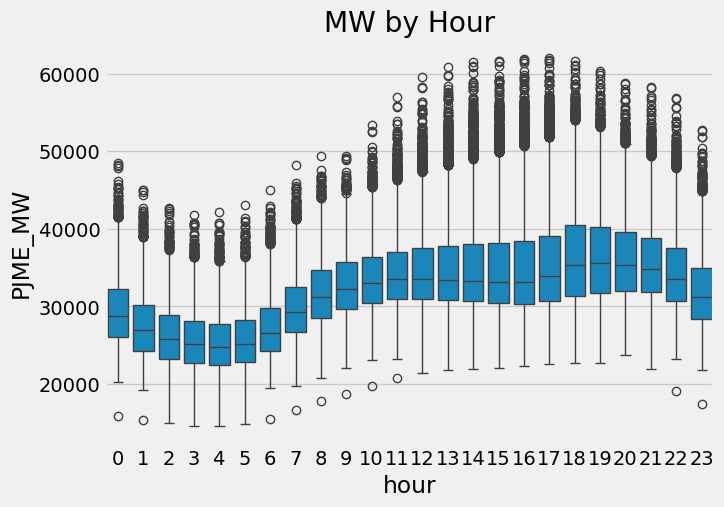

In [43]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=data, x='hour', y='PJME_MW')
ax.set_title('MW by Hour')
plt.show()

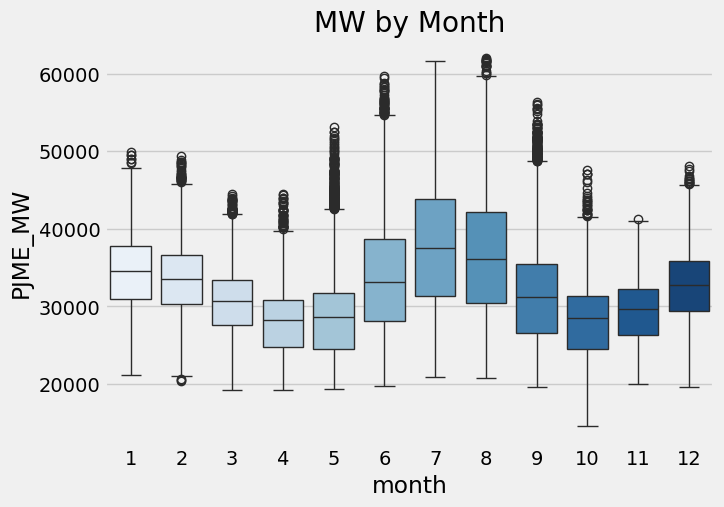

In [44]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=data, x='month', y='PJME_MW', palette='Blues')
ax.set_title('MW by Month')
plt.show()

The hourly boxplot shows that energy consumption is **lowest** during early morning hours **(1–5 AM)** and **peaks** in the late afternoon **(4–7 PM)**. The monthly boxplot confirms the **seasonal trends** observed earlier, with **higher** consumption in summer **(June–August)** and winter **(December–February)**.

# Modelisation

## Temporal Data Split for Time Series Forecasting

For our time series forecasting model, we implemented a temporal split of the dataset. The data spans from **2002 to 2018**, and we selected **January 1st, 2015** as the splitting point:

- **Training Set**: 2002–2014 (113,926 hourly observations)  
- **Test Set**: 2015–2018 (31,440 hourly observations)  

This corresponds to approximately a **78%/22% train-test split**.



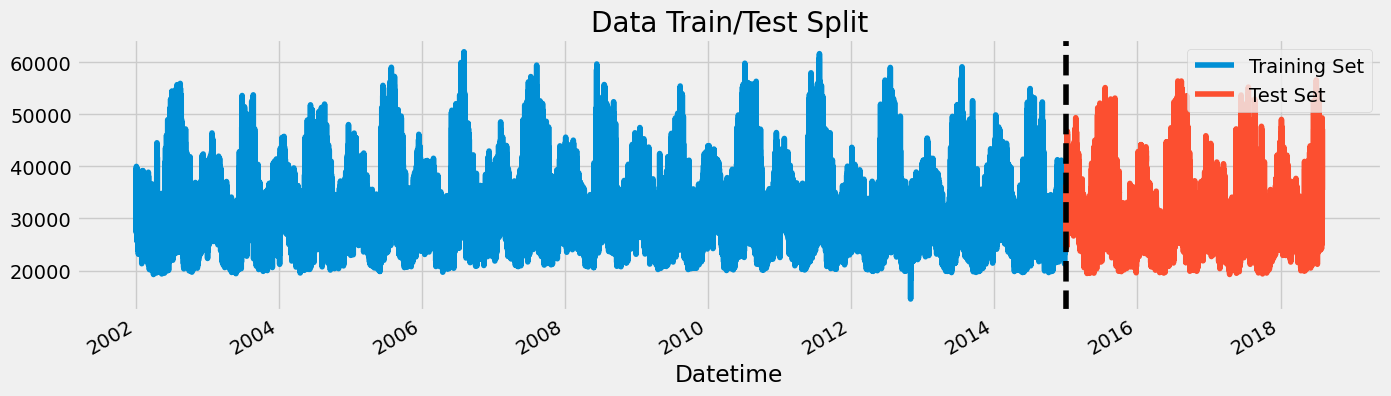

(113926, 1) (31440, 1)


In [53]:
train = df.loc[df.index < '01-01-2015']
test = df.loc[df.index >= '01-01-2015']

fig, ax = plt.subplots(figsize=(15, 4))
train.plot(ax=ax, label='Training Set', title='Data Train/Test Split')
test.plot(ax=ax, label='Test Set')
ax.axvline('01-01-2015', color='black', ls='--')
ax.legend(['Training Set', 'Test Set'])
plt.show()
print(train.shape, test.shape)

### Cross-Validation Strategy: Traditional K-Fold vs TimeSeriesSplit

When working with time series data, special consideration must be given to its temporal nature. Unlike traditional machine learning problems, time series data has an inherent temporal ordering that must be respected during the validation process.

#### Traditional K-Fold Cross-Validation
Traditional k-fold cross-validation randomly splits the data into k folds, which is inappropriate for time series data due to the following reasons:
1. **Future Data Usage**: It can use future data to predict past events.
2. **Broken Temporal Dependencies**: It disrupts the temporal structure of the data.
3. **Data Leakage**: It can lead to overoptimistic performance estimates.

#### TimeSeriesSplit

To address these issues, we employed **TimeSeriesSplit** from scikit-learn, which implements a validation strategy specifically designed for time series data. TimeSeriesSplit ensures:

- Temporal dependencies are preserved.  
- The model only learns from historical data to predict future values.  
- Validation data always follows the training data chronologically (i.e., no data leakage).

---

**TimeSeriesSplit Example**

To better understand how **TimeSeriesSplit** works, consider a simple example with 10 time points representing sequential measurements:

`X = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]`

We apply a split with 3 folds. The size of each validation set is computed using the formula:

**test size** = ⌊ N / (number of splits + 1) ⌋  

**test size** = ⌊ 10 / (3 + 1) ⌋ = 2
 - `(The "+1" ensures that the training set in the first split is larger than the test set. For example, if we divide by the number of splits only, ⌊10/3⌋ = 3, the first split would assign 1 observation to training and 3 to testing, which is not valid for time series.)`

This means each validation set will contain **2 observations**, and the training set will include all data points before that, growing progressively at each fold.

| Fold | Training Data                  | Validation Data |
|------|--------------------------------|-----------------|
| 1    | [1, 2, 3, 4]                   | [5, 6]          |
| 2    | [1, 2, 3, 4, 5, 6]             | [7, 8]          |
| 3    | [1, 2, 3, 4, 5, 6, 7, 8]       | [9, 10]         |

---

### How sizes are determined

- **Total observations (N)**: 10  
- **Number of splits**: 3  
- **Test size**: ⌊ 10 / (3 + 1) ⌋ = 2  
- **Initial training size**: 10 − (3 × 2) = 4  


### Advantages of TimeSeriesSplit

1. **Temporal Integrity**: Maintains the chronological order, respecting the sequential nature of the data.
2. **Prevention of Data Leakage**: Ensures that validation data comes after the training data, avoiding future information in training.
3. **Growing Window**: Allows the model to learn from more historical data as the window expands, simulating real-world scenarios.
4. **Realistic Evaluation**: Closely mimics practical applications where historical data is used to predict future values.


# XGBoost Model

## Feature Engineering

In this section, we extracted several new variables from our dataset to enhance the model’s ability to capture temporal patterns and dependencies. The engineered features include:

- **`hour`**: Represents the hour of the day (0–23) to identify daily usage patterns, such as peak hours.
- **`dayofweek`**: Encodes the day of the week (0–6) to distinguish between weekdays and weekends.
- **`month`**: Identifies the month of the year (1–12) to capture seasonal variations.
- **`dayofyear`**: Specifies the day of the year (1–365) to model annual trends.
- **`weekofyear`**: Denotes the week of the year (1–53) to account for weekly patterns within a year.

These variables were carefully selected after training an initial model and analyzing feature importance scores. This ensured that the chosen features significantly contributed to improving the model’s predictive performance.

#### Lagged Features
In addition to these temporal variables, we generated **lagged features** (`lag_1`, `lag_2`, ..., `lag_n`) to provide the model with historical data points. These lagged features are essential for:
- Capturing dependencies between past and future values.
- Meeting the critical requirements of time-series forecasting tasks.

The optimal number of lags (`n`) was determined through cross-validation to balance the model’s complexity and performance.

---

By incorporating these carefully engineered features, the model was equipped to better understand both long-term trends and short-term dependencies within the data, ultimately enhancing its predictive accuracy.


Lags: 1, Avg RMSE: 430.76
Lags: 4, Avg RMSE: 379.93
Lags: 8, Avg RMSE: 376.58
Lags: 12, Avg RMSE: 382.77
Lags: 24, Avg RMSE: 395.52
Lags: 48, Avg RMSE: 399.43
Lags: 72, Avg RMSE: 405.59
Lags: 96, Avg RMSE: 408.58
Lags: 168, Avg RMSE: 419.77
Best number of lags: 8, Best RMSE: 376.58
2.007466427485148 minutes
Fitting 3 folds for each of 150 candidates, totalling 450 fits
Best hyperparameters: {'subsample': 0.8, 'n_estimators': 2600, 'max_depth': 6, 'learning_rate': 0.05}
0.0 heures 47.0 minutes 27.621211290359497 secondes
RMSE Score on Test set: 282.92


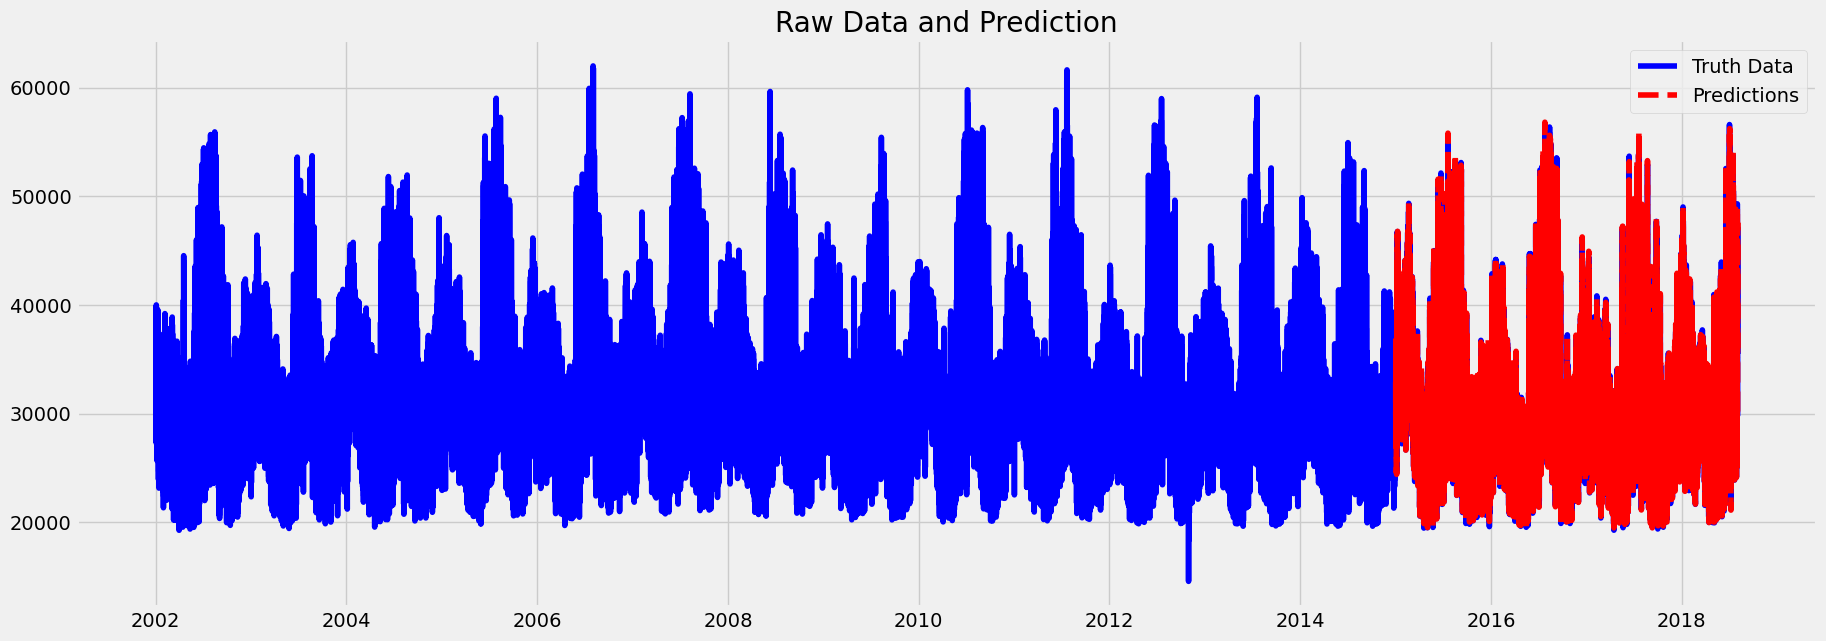

CPU times: total: 17min 23s
Wall time: 49min 47s


In [63]:
%%time
import time
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from scipy.stats import uniform, randint

b = time.time()
# Function to create features with a variable number of lags
def create_features(df, max_lags):
    df = df.copy()
    # Basic time components
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['dayofyear'] = df.index.dayofyear
    df['weekofyear'] = df.index.isocalendar().week
    # Add lagged features
    for lag in range(1, max_lags + 1):
        df[f'lag_{lag}'] = df['PJME_MW'].shift(lag)
    return df
# Split data into train and test sets
train = df.loc[df.index < '01-01-2015']
test = df.loc[df.index >= '01-01-2015']

# Define target variable
TARGET = 'PJME_MW'

# Cross-validation for lag selection
best_lags = None
best_rmse = float('inf')
lags_to_test = [1, 4, 8, 12, 24, 48, 72, 96, 168]  # 1 hour, 4 hours, 8 hours, 12 hours, a day, 2 days ... a week.

for lags in lags_to_test:
    # Create features with the current number of lags
    train_lags = create_features(train, lags)
    train_lags.dropna(inplace=True)  # Drop rows with NaN values due to lagging

    # Define features and target
    FEATURES = [col for col in train_lags.columns if col != TARGET]
    X = train_lags[FEATURES]
    y = train_lags[TARGET]

    # TimeSeriesSplit for cross-validation
    tscv = TimeSeriesSplit(n_splits=3)
    rmse_scores = []
    # Perform cross-validation to find the best number of lags
    # Iterate through each fold of the TimeSeriesSplit
    for train_index, val_index in tscv.split(X):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]

        # Train a simple XGBoost model
        model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=200, learning_rate=0.1, n_jobs=-1)
        model.fit(X_train, y_train)

        # Evaluate on the validation set
        predictions = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, predictions))
        rmse_scores.append(rmse)

    # Average RMSE across folds
    avg_rmse = np.mean(rmse_scores)
    print(f'Lags: {lags}, Avg RMSE: {avg_rmse:.2f}')

    # Update best lags if current RMSE is better
    if avg_rmse < best_rmse:
        best_rmse = avg_rmse
        best_lags = lags

print(f'Best number of lags: {best_lags}, Best RMSE: {best_rmse:.2f}')
f = time.time()
print((f-b)/60, "minutes")

# Create features with the best number of lags
train = create_features(train, best_lags)
test = create_features(test, best_lags)
train.dropna(inplace=True)
test.dropna(inplace=True)

# Define features and target
FEATURES = [col for col in train.columns if col != TARGET]
X_train = train[FEATURES]
y_train = train[TARGET]
X_test = test[FEATURES]
y_test = test[TARGET]

# Randomized Search for hyperparameter tuning, using TimeSeriesSplit for cross-validation, we perform corse_to_fine search, the next code is the last step of this methodology.
# We will use RandomizedSearchCV to find the best hyperparameters for the XGBoost model.
param_dist = {
    'n_estimators': [2300, 2400, 2500, 2600],
    'learning_rate': [0.001, 0.01, 0.02, 0.05],
    'max_depth': [2, 4, 6, None],
    'subsample': [0.8, 0.9, 1.0]
}
b = time.time()

model = xgb.XGBRegressor(objective='reg:squarederror', n_jobs=-1)
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=150,
    scoring='neg_mean_squared_error',
    cv=TimeSeriesSplit(n_splits=3),
    verbose=2,
    random_state=42, n_jobs=-1
)
random_search.fit(X_train, y_train)

# Best hyperparameters
print(f'Best hyperparameters: {random_search.best_params_}')
f = time.time()
n = f-b

a = (n)//3600 
b = ((n) - a*3600 )//60
c = ((n) - a*3600 - b*60)
print(a, "heures", b, "minutes", c, "secondes")


# Train final model with best hyperparameters
best_model = random_search.best_estimator_
best_model.fit(X_train, y_train)

# Get predictions
predictions = best_model.predict(X_test)

# Evaluate model
score = np.sqrt(mean_squared_error(y_test, predictions))
print(f'RMSE Score on Test set: {score:.2f}')

# Plot predictions vs actual values
plt.figure(figsize=(20, 7))
plt.plot(df.index,df.PJME_MW, label='Truth Data', color='blue')
plt.plot(test.index, predictions, label='Predictions', color='red', linestyle='--')
plt.legend()
plt.title('Raw Data and Prediction')
plt.show()

In [64]:
print(f"The Train error is {np.sqrt(mean_squared_error(y_train, best_model.predict(X_train)))}")

The Train error is 174.69009217713392


### Determining the Optimal Number of Lags

To determine the optimal number of lagged features for our time-series model, we conducted a systematic evaluation using a predefined range of lags: **1, 4, 8, 12, 24, 48, 72, 96, and 168**. These values correspond to various time intervals, including:
- **1 hour**: Capturing immediate past dependencies.
- **4 hours**: Reflecting intra-day patterns.
- **12 and 24 hours**: Half-day and daily cycles.
- **48 to 168 hours**: Multi-day and weekly trends.

#### Methodology
1. **Lagged Feature Creation**:
   - For each lag value, lagged features were generated by shifting the target variable by the specified number of time steps.
   - These lagged features provide historical context about the target variable, helping the model capture temporal dependencies.
   - Rows with missing values due to lagging were removed to ensure data integrity.

2. **Performance Evaluation**:
   - A **time-series cross-validation (TSCV)** approach with **three splits** was used for evaluation.
   - For each fold:
     - An initial **XGBoost model** was trained on the training set.
     - The model’s performance was assessed on the validation set using the **Root Mean Squared Error (RMSE)** metric.
   - The **average RMSE across the three folds** was calculated for each lag configuration.

3. **Optimal Lag Selection**:
   - The lag value corresponding to the **lowest average RMSE** was selected as the optimal number of lags.

### Results
The evaluation showed that a **lag of 8** yielded the best performance, with an **average RMSE of 376.58**. This result suggests that including information from the previous **8 hours** provides the most significant predictive value for the target variable.




### Hyperparameter Tuning with Randomized Search

To optimize the performance of our **XGBoost model**, we applied a systematic hyperparameter tuning approach using the **coarse-to-fine method**. This method reduces computational cost while ensuring that the best hyperparameter configurations are identified. 

#### Coarse-to-Fine Tuning
1. **Coarse Search**:
   - Begins with exploring a wide range of hyperparameter values in broader intervals.
2. **Fine Search**:
   - Narrows down the promising ranges identified during the coarse search and performs a more focused search in finer intervals.

#### Coarse Search Parameter Space
In the coarse search finale phase, the following hyperparameters ranges were defined:

- **`n_estimators`**: [2300, 2400, 2500, 2600]
- **`learning_rate`**: [0.001, 0.01, 0.02, 0.05]
- **`max_depth`**: [2, 4, 6, None]
- **`subsample`**: [0.8, 0.9, 1.0]

---

#### Randomized Search Implementation
We utilized the **`RandomizedSearchCV`** function from scikit-learn to perform the search:
- **Sampling**: A fixed number of parameter combinations (**n_iter=150**) were sampled from the defined space.
- **Cross-Validation**: Used **three-fold time-series cross-validation** (`TimeSeriesSplit`) to preserve the temporal structure of the data.
- **Scoring Metric**: Negative Mean Squared Error (**neg_mean_squared_error**) was used to minimize prediction error.

The randomized search evaluated a total of **450 models** (150 parameter combinations evaluated across 3 folds).

---

#### Best Configuration
The best hyperparameter configuration identified was:
- **`subsample`**: 0.8
- **`n_estimators`**: 2600
- **`max_depth`**: 6
- **`learning_rate`**: 0.05

---

#### Computational Details
- The entire tuning process required approximately **49 minutes and 47 seconds**, utilizing **all 8 cores** of my machine.
- This efficient approach enabled us to balance computational cost and performance.



### Model Evaluation and Results

The **Root Mean Squared Error (RMSE)** is a widely used metric for evaluating regression models. 

The RMSE measures the average magnitude of the error between predicted and actual values. A **lower RMSE** indicates better model performance, reflecting smaller prediction errors.

---

#### Results
- **RMSE on Test Set**: **282.92**
- **Target Variable Range**: Approximately 20,000 to 60,000.
- **Interpretation**:
  - The RMSE indicates that the model’s predictions deviate from the actual values by an average of less than **300 units**.
  - This error represents less than **1% of the total range**, demonstrating the model’s high accuracy.

---

#### Visual Representation
The graph comparing the **actual energy demand (blue line)** and the **predicted values (red dashed line)** provides a clear visual of the model’s performance:
- The strong alignment between the two lines, especially in the **test set (highlighted in red)**, underscores the model's ability to:
  - Capture seasonal trends.
  - Track smaller fluctuations effectively.


# Fin